# Model 1A, Experiment 01: Compact Engineered CatBoost

This notebook evaluates CatBoost for predicting whether a JFK departure will be at least 15 minutes late. It uses the exact 34-field compact non-backlog source manifest from Decision Tree Experiment 02 and Random Forest Experiment 01. The controlled change is the classifier and CatBoost's native handling of categorical fields.

The experiment preserves chronology and all evaluation rules: hyperparameters and tree count are selected only from five expanding-window folds within 2019, the operating threshold is selected only from held-out 2019 probabilities, the selected model is refitted on all 2019 rows, and 2023 is evaluated once as external development/validation. The 2024 dataset is not loaded.


In [1]:
# Parameters
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 4
MAX_ITERATIONS = 1000
EARLY_STOPPING_ROUNDS = 75


In [2]:
from itertools import product
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost version: {catboost.__version__}")


CatBoost version: 1.2.10


## Load and validate the shared departure feature data

The path lookup supports execution from either the project root or the `models` directory. Only the standard non-backlog departure files are loaded.


In [3]:
def find_project_root(start: Path, airport: str, years) -> Path:
    relative_paths = [Path("data/features") / f"{airport}_{year}_departures.csv" for year in years]
    for candidate in (start, *start.parents):
        if all((candidate / path).exists() for path in relative_paths):
            return candidate
    raise FileNotFoundError(f"Could not locate all required files: {relative_paths}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve(), AIRPORT, [TRAIN_YEAR, VALIDATION_YEAR])
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_departures.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_departures.csv"
train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)
print(f"Training source: {TRAIN_DATA_PATH}")
print(f"Training rows: {len(train_df):,}; columns: {train_df.shape[1]:,}")
print(f"Validation source: {VALIDATION_DATA_PATH}")
print(f"Validation rows: {len(validation_df):,}; columns: {validation_df.shape[1]:,}")


Training source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2019_departures.csv
Training rows: 107,430; columns: 106
Validation source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/features/JFK_2023_departures.csv
Validation rows: 109,983; columns: 106


In [4]:
def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Origin", TARGET}
    assert not (required - set(frame.columns)), f"{partition} missing audit columns"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="coerce")
    assert frame["FlightDate"].notna().all()
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Origin"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition, "year": year,
        "start": frame["FlightDate"].min().date(), "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(), "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()), "delay_rate": frame[TARGET].mean(),
    }

source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary


,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107430,20168,0.1877
external validation,2023,2023-01-01,2023-12-31,365,109983,25995,0.2364


## Exact compact non-backlog feature manifest

The six categorical fields remain native CatBoost categories rather than becoming one-hot columns. Missing categorical values receive the explicit label `MISSING`; numeric fields remain numeric and missing numeric values remain `NaN` for CatBoost to handle. No imputation, scaling, target encoding outside CatBoost, backlog field, or post-pushback outcome is used.


In [5]:
categorical_features = [
    "Month", "DayOfWeek", "Reporting_Airline", "Dest", "TIME_OF_DAY", "AIRLINE_DEST",
]
numeric_features = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance", "IS_WEEKEND",
    "SCHEDULED_SPEED_PROXY", "ASPM_PREVIOUS_SCHEDULED_DEPARTURES",
    "ASPM_PREVIOUS_SCHEDULED_ARRIVALS", "ASPM_CURRENT_SCHEDULED_DEPARTURES",
    "ASPM_CURRENT_SCHEDULED_ARRIVALS", "ASPM_NEXT_SCHEDULED_DEPARTURES",
    "ASPM_NEXT_SCHEDULED_ARRIVALS", "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS", "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC", "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature", "TEMP_DEWPOINT_SPREAD", "LOG_PRECIPITATION",
    "HourlyRelativeHumidity", "HourlyVisibility", "HourlyWindSpeed", "WindX", "WindY",
    "WEATHER_CONDITION_COUNT", "ADVERSE_WEATHER", "NOAA_AGE_MINUTES",
]
feature_columns = categorical_features + numeric_features
required_columns = ["FlightDate", "Origin", TARGET, *feature_columns]
assert len(feature_columns) == 34 and len(feature_columns) == len(set(feature_columns))
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns) - set(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"
forbidden = {TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut", "WheelsOff",
             "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay", "ArrDel15", "ActualElapsedTime",
             "AirTime", "Tail_Number"}
assert not forbidden.intersection(feature_columns)
assert not any(column.startswith("BACKLOG_") for column in feature_columns)
print(f"Selected {len(feature_columns)} compact non-backlog predictors")
print(f"  native categorical: {len(categorical_features)}")
print(f"  numeric: {len(numeric_features)}")


Selected 34 compact non-backlog predictors
  native categorical: 6
  numeric: 28


In [6]:
def prepare_model_frame(source_frame: pd.DataFrame) -> pd.DataFrame:
    frame = source_frame[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = frame[TARGET].astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame

train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train = train_model_df[feature_columns].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
X_validation = validation_model_df[feature_columns].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
assert training_dates.max() < validation_dates.min()
missing_summary = pd.DataFrame({
    "training_missing": X_train.isna().sum(), "validation_missing": X_validation.isna().sum(),
})
display(missing_summary[missing_summary.sum(axis=1).gt(0)])


,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
ASPM_THREE_HOUR_SCHEDULED_DEPARTURES,1,0
ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,1,0
ASPM_NEXT_MINUS_CURRENT_TRAFFIC,1,0
ASPM_MAX_HOURLY_TRAFFIC,1,0
TEMP_DEWPOINT_SPREAD,46,0
LOG_PRECIPITATION,22,21
HourlyVisibility,0,28
WindX,54,87


## Expanding-window temporal folds

The same complete-day folds used by the logistic, decision-tree, and Random Forest experiments preserve chronology. CatBoost's ordered categorical statistics are additionally kept within each fold because every model is fitted only on that fold's earlier rows.


In [7]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized_dates = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized_dates)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []
    for fold_number in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold_number])
        validation_days = day_blocks[fold_number]
        train_indices = np.flatnonzero(np.isin(normalized_dates, train_days))
        validation_indices = np.flatnonzero(np.isin(normalized_dates, validation_days))
        assert train_days.max() < validation_days.min()
        splits.append((train_indices, validation_indices))
        rows.append({
            "fold": fold_number, "train_start": pd.Timestamp(train_days.min()).date(),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(validation_days.min()).date(),
            "validation_end": pd.Timestamp(validation_days.max()).date(),
            "train_rows": len(train_indices), "validation_rows": len(validation_indices),
            "train_delay_rate": targets.iloc[train_indices].mean(),
            "validation_delay_rate": targets.iloc[validation_indices].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")

temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
partition_summary = pd.DataFrame({
    "start": [training_dates.min().date(), validation_dates.min().date()],
    "end": [training_dates.max().date(), validation_dates.max().date()],
    "days": [training_dates.dt.normalize().nunique(), validation_dates.dt.normalize().nunique()],
    "rows": [len(y_train), len(y_validation)],
    "delayed_flights": [y_train.sum(), y_validation.sum()],
    "delay_rate": [y_train.mean(), y_validation.mean()],
}, index=["2019 training", "2023 external validation"])
display(partition_summary)
fold_summary


,start,end,days,rows,delayed_flights,delay_rate
2019 training,2019-01-01,2019-12-31,365,107430,20168,0.1877
2023 external validation,2023-01-01,2023-12-31,365,109983,25995,0.2364


,train_start,train_end,validation_start,validation_end,train_rows,validation_rows,train_delay_rate,validation_delay_rate
fold,,,,,,,,
1,2019-01-01,2019-03-02,2019-03-03,2019-05-02,17737,18776,0.1892,0.1674
2,2019-01-01,2019-05-02,2019-05-03,2019-07-02,36513,18150,0.1780,0.2072
3,2019-01-01,2019-07-02,2019-07-03,2019-09-01,54663,17758,0.1877,0.2577
4,2019-01-01,2019-09-01,2019-09-02,2019-11-01,72421,17686,0.2048,0.1384
5,2019-01-01,2019-11-01,2019-11-02,2019-12-31,90107,17323,0.1918,0.1666


## Manual temporal search with fold-local early stopping

Sixteen deliberately compact configurations compare depths 4 and 6, learning rates 0.03 and 0.10, L2 leaf regularization 3 and 10, and no class weighting versus CatBoost's automatic balanced weighting. Each fit allows at most 1,000 iterations and stops after 75 iterations without improvement in validation PRAUC. Average precision calculated from predictions, rather than CatBoost's internal metric value, ranks configurations.

Weighting is learned and applied only inside each training fold. Validation and test populations retain their observed class distributions. A later imbalance experiment can still examine a broader range of weighting and resampling methods under the common protocol.


In [8]:
parameter_candidates = [
    {"depth": depth, "learning_rate": rate, "l2_leaf_reg": regularization,
     "class_weighting": class_weighting}
    for depth, rate, regularization, class_weighting
    in product([4, 6], [0.03, 0.10], [3, 10], ["None", "Balanced"])
]

def make_catboost_model(parameters, iterations=MAX_ITERATIONS, use_best_model=True):
    return CatBoostClassifier(
        iterations=iterations, loss_function="Logloss", eval_metric="PRAUC:type=Classic",
        depth=parameters["depth"], learning_rate=parameters["learning_rate"],
        l2_leaf_reg=parameters["l2_leaf_reg"],
        auto_class_weights=None if parameters["class_weighting"] == "None" else parameters["class_weighting"],
        random_seed=RANDOM_STATE,
        thread_count=N_JOBS, allow_writing_files=False, verbose=False, use_best_model=use_best_model,
    )

search_start = perf_counter()
search_rows = []
for candidate_number, parameters in enumerate(parameter_candidates, start=1):
    for fold_number, (train_indices, validation_indices) in enumerate(temporal_splits, start=1):
        model = make_catboost_model(parameters)
        model.fit(
            X_train.iloc[train_indices], y_train.iloc[train_indices],
            cat_features=categorical_features,
            eval_set=(X_train.iloc[validation_indices], y_train.iloc[validation_indices]),
            early_stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False,
        )
        probabilities = model.predict_proba(X_train.iloc[validation_indices])[:, 1]
        search_rows.append({
            "candidate": candidate_number, "fold": fold_number, **parameters,
            "best_iteration": model.get_best_iteration() + 1,
            "average_precision": average_precision_score(y_train.iloc[validation_indices], probabilities),
            "roc_auc": roc_auc_score(y_train.iloc[validation_indices], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[validation_indices], probabilities),
        })
    print(f"Completed candidate {candidate_number}/{len(parameter_candidates)}: {parameters}")

search_seconds = perf_counter() - search_start
fold_search_results = pd.DataFrame(search_rows)
candidate_results = (
    fold_search_results.groupby(
        ["candidate", "depth", "learning_rate", "l2_leaf_reg", "class_weighting"], as_index=False)
    .agg(mean_average_precision=("average_precision", "mean"),
         std_average_precision=("average_precision", "std"),
         mean_roc_auc=("roc_auc", "mean"), mean_brier_score=("brier_score", "mean"),
         median_best_iteration=("best_iteration", "median"),
         min_best_iteration=("best_iteration", "min"), max_best_iteration=("best_iteration", "max"))
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False)
)
best_candidate = candidate_results.iloc[0]
selected_parameters = {
    "depth": int(best_candidate["depth"]),
    "learning_rate": float(best_candidate["learning_rate"]),
    "l2_leaf_reg": float(best_candidate["l2_leaf_reg"]),
    "class_weighting": str(best_candidate["class_weighting"]),
}
selected_iterations = int(best_candidate["median_best_iteration"])
print(f"Temporal search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation average precision: {best_candidate['mean_average_precision']:.4f}")
print(f"Selected parameters: {selected_parameters}")
print(f"Selected iteration count (median fold best): {selected_iterations}")
candidate_results


Completed candidate 1/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 2/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 3/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 4/16: {'depth': 4, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}


Completed candidate 5/16: {'depth': 4, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


...

Completed candidate 13/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'None'}


Completed candidate 14/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'class_weighting': 'Balanced'}


Completed candidate 15/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'None'}


Completed candidate 16/16: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10, 'class_weighting': 'Balanced'}
Temporal search completed in 305.4 seconds
Best mean temporal-validation average precision: 0.3459
Selected parameters: {'depth': 6, 'learning_rate': 0.1, 'l2_leaf_reg': 10.0, 'class_weighting': 'None'}
Selected iteration count (median fold best): 45


,candidate,depth,learning_rate,l2_leaf_reg,class_weighting,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score,median_best_iteration,min_best_iteration,max_best_iteration
14,15,6,0.1000,10,None,0.3459,0.0834,0.6772,0.1547,45.0000,7,202
12,13,6,0.1000,3,None,0.3405,0.0878,0.6765,0.1668,43.0000,1,107
10,11,6,0.0300,10,None,0.3387,0.0883,0.6768,0.1818,30.0000,1,291
8,9,6,0.0300,3,None,0.3387,0.0927,0.6750,0.1858,20.0000,1,631
7,8,4,0.1000,10,Balanced,0.3367,0.0875,0.6798,0.2334,174.0000,46,295
2,3,4,0.0300,10,None,0.3363,0.0936,0.6760,0.1854,18.0000,1,532
6,7,4,0.1000,10,None,0.3358,0.0939,0.6776,0.1684,62.0000,1,157
0,1,4,0.0300,3,None,0.3342,0.0906,0.6759,0.1698,108.0000,1,542
15,16,6,0.1000,10,Balanced,0.3320,0.0902,0.6761,0.2364,92.0000,12,131
5,6,4,0.1000,3,Balanced,0.3310,0.0841,0.6794,0.2360,47.0000,13,303


## Select the operating threshold using 2019 only

The selected parameters and fixed median tree count are refitted on each expanding training fold. This produces one held-out probability for every row in folds 1 through 5 without using any later row or any 2023 outcome. Thresholds from 0.05 through 0.50 are ranked by F1, with balanced accuracy and precision as tie-breakers.


Threshold-selection rows: 89,693
Training-only selected threshold: 0.19


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc
14,0.1900,0.5632,0.6074,0.2524,0.6782,0.3679,0.1677
13,0.1800,0.5398,0.6066,0.2475,0.7134,0.3675,0.1669
15,0.2000,0.5865,0.6065,0.2572,0.6387,0.3667,0.1667
12,0.1700,0.5171,0.6049,0.2430,0.7455,0.3666,0.1657
16,0.2100,0.6094,0.6053,0.2624,0.5989,0.3650,0.1662
11,0.1600,0.4948,0.6016,0.2384,0.7725,0.3643,0.1624
17,0.2200,0.6307,0.6041,0.2682,0.5615,0.3630,0.1664
10,0.1500,0.4729,0.5985,0.2344,0.7994,0.3625,0.1601
9,0.1400,0.4490,0.5950,0.2304,0.8286,0.3605,0.1582
18,0.2300,0.6502,0.6019,0.2739,0.5247,0.3599,0.1658


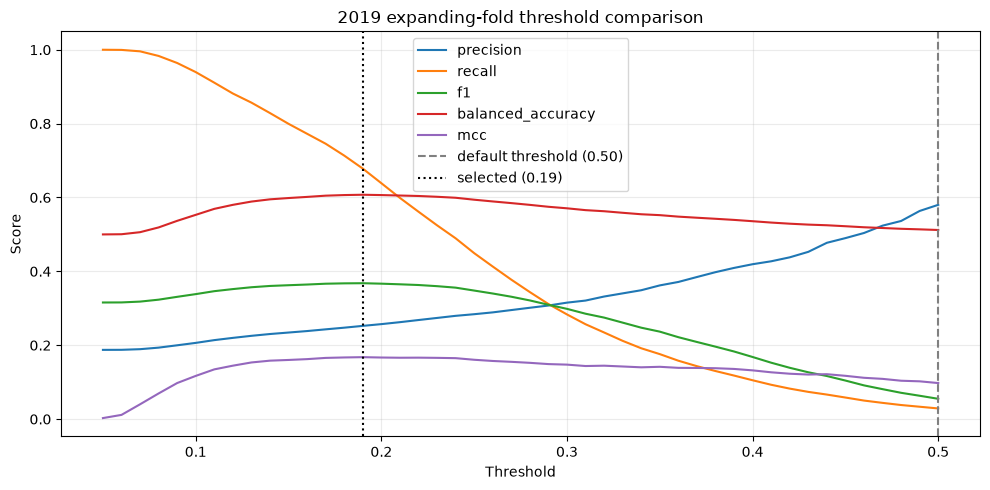

In [9]:
oof_probabilities = np.full(len(y_train), np.nan)
for train_indices, validation_indices in temporal_splits:
    fold_model = make_catboost_model(selected_parameters, iterations=selected_iterations, use_best_model=False)
    fold_model.fit(X_train.iloc[train_indices], y_train.iloc[train_indices],
                   cat_features=categorical_features, verbose=False)
    oof_probabilities[validation_indices] = fold_model.predict_proba(X_train.iloc[validation_indices])[:, 1]
oof_mask = np.isfinite(oof_probabilities)
oof_y, oof_p = y_train.to_numpy()[oof_mask], oof_probabilities[oof_mask]
threshold_rows = []
for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2):
    predictions = (oof_p >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold, "accuracy": accuracy_score(oof_y, predictions),
        "balanced_accuracy": balanced_accuracy_score(oof_y, predictions),
        "precision": precision_score(oof_y, predictions, zero_division=0),
        "recall": recall_score(oof_y, predictions, zero_division=0),
        "f1": f1_score(oof_y, predictions, zero_division=0),
        "mcc": matthews_corrcoef(oof_y, predictions),
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"], ascending=False).iloc[0]
selected_threshold = float(best_threshold_row["threshold"])
print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
display(threshold_results.sort_values(["f1", "balanced_accuracy", "precision"], ascending=False).head(10))
fig, ax = plt.subplots(figsize=(10, 5))
for metric in ["precision", "recall", "f1", "balanced_accuracy", "mcc"]:
    ax.plot(threshold_results["threshold"], threshold_results[metric], label=metric)
ax.axvline(0.50, color="gray", linestyle="--", label="default threshold (0.50)")
ax.axvline(selected_threshold, color="black", linestyle=":", label=f"selected ({selected_threshold:.2f})")
ax.set(title="2019 expanding-fold threshold comparison", xlabel="Threshold", ylabel="Score")
ax.grid(alpha=0.25); ax.legend(); plt.tight_layout(); plt.show()


## Refit on all 2019 rows and evaluate 2023

The final development model uses the selected parameters and the median best iteration count from the five training folds. It trains on every 2019 row without an evaluation set, so no 2019 rows are withheld and no 2023 label influences fitting or early stopping.


In [10]:
final_fit_start = perf_counter()
best_catboost_model = make_catboost_model(selected_parameters, iterations=selected_iterations, use_best_model=False)
best_catboost_model.fit(X_train, y_train, cat_features=categorical_features, verbose=False)
final_fit_seconds = perf_counter() - final_fit_start
print(f"Final all-2019 fit completed in {final_fit_seconds:,.1f} seconds")
print(f"Fitted trees: {best_catboost_model.tree_count_:,}")


Final all-2019 fit completed in 1.1 seconds
Fitted trees: 45


In [11]:
def evaluate_probabilities(y_true, probabilities, model_name, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "model": model_name, "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }

validation_probabilities = best_catboost_model.predict_proba(X_validation)[:, 1]
dummy_model = DummyClassifier(strategy="prior").fit(X_train, y_train)
dummy_probabilities = dummy_model.predict_proba(X_validation)[:, 1]
evaluation_results = pd.DataFrame([
    evaluate_probabilities(y_validation, dummy_probabilities, "Dummy (2019 class prior)", 0.50),
    evaluate_probabilities(y_validation, validation_probabilities, "CatBoost (default threshold)", 0.50),
    evaluate_probabilities(y_validation, validation_probabilities, "CatBoost (training-selected threshold)", selected_threshold),
]).set_index("model")
evaluation_results


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Dummy (2019 class prior),0.5000,0.7636,0.5000,0.0000,0.0000,0.0000,0.0000,0.5000,0.2364,0.1829
CatBoost (default threshold),0.5000,0.7655,0.5065,0.6706,0.0153,0.0299,0.0752,0.6886,0.4104,0.1692
CatBoost (training-selected threshold),0.1900,0.6594,0.6349,0.3637,0.5884,0.4495,0.2358,0.6886,0.4104,0.1692


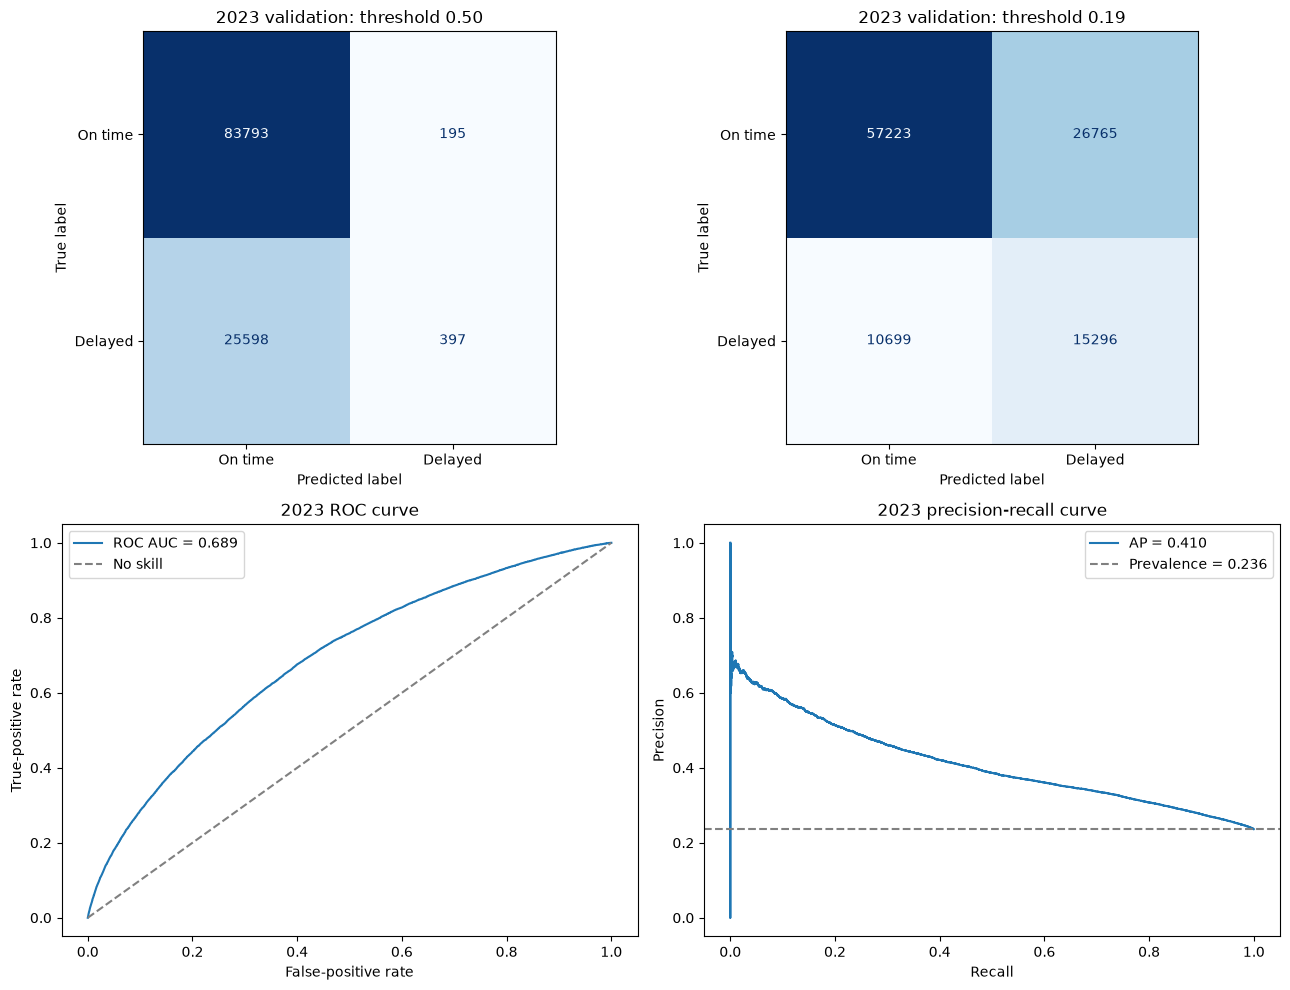

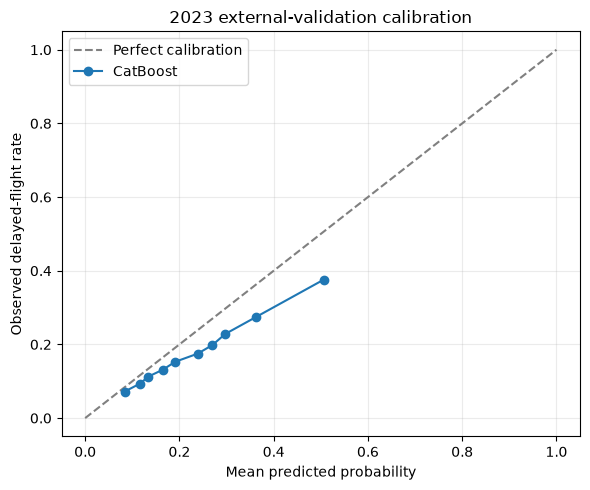

In [12]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, validation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, validation_probabilities)
calibration_predicted, calibration_observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile")
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(y_validation, default_predictions, display_labels=["On time", "Delayed"],
    cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title("2023 validation: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(y_validation, selected_predictions, display_labels=["On time", "Delayed"],
    cmap="Blues", colorbar=False, ax=axes[0, 1])
axes[0, 1].set_title(f"2023 validation: threshold {selected_threshold:.2f}")
axes[1, 0].plot(false_positive_rate, true_positive_rate, label=f"ROC AUC = {roc_auc_score(y_validation, validation_probabilities):.3f}")
axes[1, 0].plot([0, 1], [0, 1], "--", color="gray", label="No skill")
axes[1, 0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="2023 ROC curve"); axes[1, 0].legend()
axes[1, 1].plot(curve_recall, curve_precision, label=f"AP = {average_precision_score(y_validation, validation_probabilities):.3f}")
axes[1, 1].axhline(y_validation.mean(), linestyle="--", color="gray", label=f"Prevalence = {y_validation.mean():.3f}")
axes[1, 1].set(xlabel="Recall", ylabel="Precision", title="2023 precision-recall curve"); axes[1, 1].legend()
fig.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.plot(calibration_predicted, calibration_observed, marker="o", label="CatBoost")
ax.set(xlabel="Mean predicted probability", ylabel="Observed delayed-flight rate",
       title="2023 external-validation calibration"); ax.grid(alpha=0.25); ax.legend()
plt.tight_layout(); plt.show()


## Inspect CatBoost feature importance

CatBoost's default prediction-value-change importance is reported for the original 34 source fields. It is descriptive rather than causal and may distribute importance among correlated schedule, traffic, and weather fields.


,feature,importance
6,CRSDepTime,16.6675
23,HourlyDryBulbTemperature,11.0158
0,Month,10.2939
19,ASPM_THREE_HOUR_SCHEDULED_ARRIVALS,10.2161
24,TEMP_DEWPOINT_SPREAD,6.2553
26,HourlyRelativeHumidity,5.7301
2,Reporting_Airline,4.8772
22,ASPM_MAX_HOURLY_TRAFFIC,4.4330
5,AIRLINE_DEST,3.2369
28,HourlyWindSpeed,3.1600


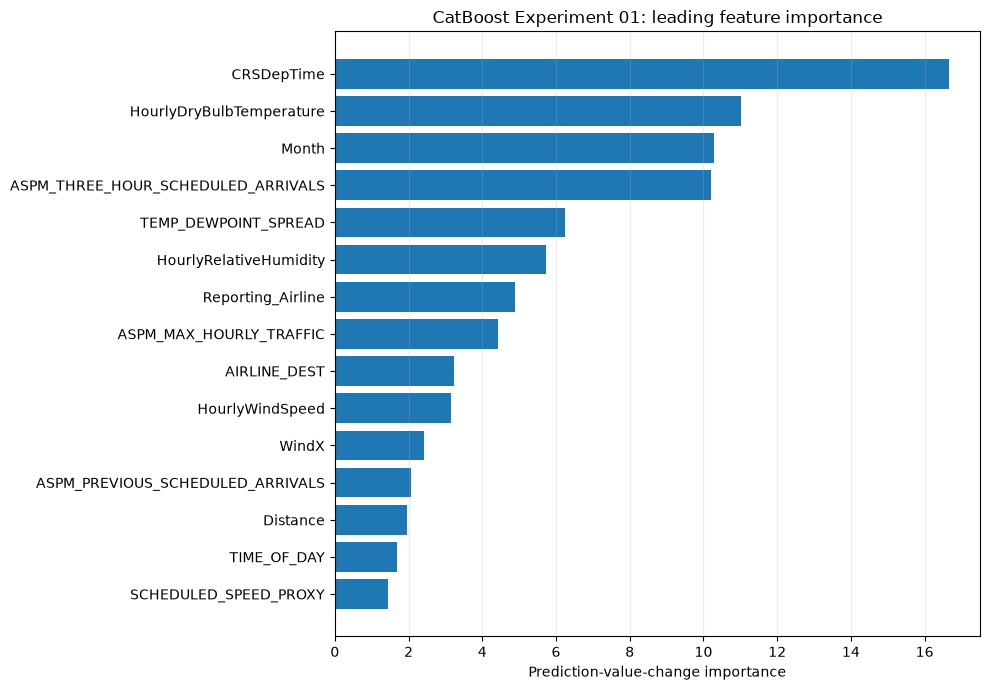

In [13]:
feature_importance = (pd.DataFrame({
    "feature": feature_columns, "importance": best_catboost_model.get_feature_importance(),
}).sort_values("importance", ascending=False))
display(feature_importance.head(20))
top_importance = feature_importance.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_importance["feature"], top_importance["importance"])
ax.set(title="CatBoost Experiment 01: leading feature importance", xlabel="Prediction-value-change importance")
ax.grid(axis="x", alpha=0.25); plt.tight_layout(); plt.show()


## CatBoost Experiment 01 interpretation checklist

1. Does CatBoost improve temporal and external-validation average precision over the Random Forest and single tree using the identical source manifest?
2. Does the improvement extend to ROC AUC, Brier score, calibration, F1, and MCC?
3. Are the selected depth, learning rate, regularization, and fold-specific iteration counts stable and practical?
4. Does native categorical handling give airline, destination, time-of-day, or airline-destination meaningful importance?
5. Do ASPM congestion fields remain important alongside schedule and weather?
6. Does this non-backlog CatBoost baseline justify a separately numbered backlog experiment?

Treat 2023 as external development/validation only. Its results may motivate a new append-only experiment but must not alter this fitted experiment. Keep 2024 locked until the final design and operating threshold are selected.
